In [174]:
#load in packages 
import numpy as np
import pandas as pd

#regex
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.multiclass import OneVsRestClassifier

from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import GridSearchCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, accuracy_score, top_k_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

import matplotlib.pyplot as plt


In [1]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import words

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import words

In [3]:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jarem\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jarem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jarem\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
import nltk

nltk.download('punkt')        # For word_tokenize
nltk.download('stopwords')    # For stopwords
nltk.download('wordnet')      # For WordNetLemmatizer
nltk.download('words')        # For nltk.corpus.words


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jarem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jarem\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jarem\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\jarem\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [5]:
items_df = pd.read_csv("categorized_items4.csv").iloc[:, 2:]
items_df.dropna()
items_df["processed"] = items_df["processed"].astype(str)

In [6]:
items_df.head(1)

,store_id,product_id,product_title_x,summary_x,description_x,TSD_x,breadcrumb_clean_x,TSDB,processed,breadcrumb_clean_y,category
0,2,1111071,"Sainsbury's Thick Bleach, Lemon 2L",Thick Bleach Citrus,Thick Bleach Citrus\nwith limescale deterrent\...,"Sainsbury's Thick Bleach, Lemon 2L Thick Bleac...",Groceries | Household | Household essentials |...,"Sainsbury's Thick Bleach, Lemon 2L Thick Bleac...",thick bleach lemon l thick bleach citrus thick...,Groceries | Household | Household essentials |...,Cleaning Liquid


In [7]:
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5976 entries, 0 to 5975
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   store_id            5976 non-null   int64 
 1   product_id          5976 non-null   int64 
 2   product_title_x     5976 non-null   object
 3   summary_x           5709 non-null   object
 4   description_x       4766 non-null   object
 5   TSD_x               5976 non-null   object
 6   breadcrumb_clean_x  5976 non-null   object
 7   TSDB                5976 non-null   object
 8   processed           5976 non-null   object
 9   breadcrumb_clean_y  5976 non-null   object
 10  category            5976 non-null   object
dtypes: int64(2), object(9)
memory usage: 513.7+ KB


In [8]:
items_df.head(1)

,store_id,product_id,product_title_x,summary_x,description_x,TSD_x,breadcrumb_clean_x,TSDB,processed,breadcrumb_clean_y,category
0,2,1111071,"Sainsbury's Thick Bleach, Lemon 2L",Thick Bleach Citrus,Thick Bleach Citrus\nwith limescale deterrent\...,"Sainsbury's Thick Bleach, Lemon 2L Thick Bleac...",Groceries | Household | Household essentials |...,"Sainsbury's Thick Bleach, Lemon 2L Thick Bleac...",thick bleach lemon l thick bleach citrus thick...,Groceries | Household | Household essentials |...,Cleaning Liquid


## Create union for breadcrumb and processed and lemmatise

In [9]:
#stop_words = stopwords.words('english')
#english_words = set(words.words())

In [10]:
#df = items_df.copy()
#df['text'] = df['processed'].astype(str) + ' ' + df['breadcrumb_clean'].astype(str)

In [11]:
# Preprocessing function
#def preprocess_text(text):
    #text = text.lower() # Lowercase
    #text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation
    #tokens = word_tokenize(text) # Tokenize
    #lemmatizer = WordNetLemmatizer()
    #tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lemmatize
    #tokens = [word for word in tokens if word not in stopwords.words('english')] # Remove stopwords
    #tokens = [word for word in tokens if word in english_words] # Remove non-english words
    #return " ".join(tokens)

# Apply preprocessing
#df['text'] = df['text'].apply(preprocess_text)

## Assign gender

In [12]:
# Function to classify gender based on the description

def classify_gender(descr):
    # Define regex patterns for male, female, and neutral categories 
    male_pattern = r'\b(male|men|mens|man|mans|masculine|him|for him|his|gentleman|gentlemen|testosterone)\b'
    female_pattern = r'\b(feminine|for her|her|hers|women|female|womans|womens|woman|makeup|make up|nailpolish|nail polish|girl|girls|ladies|ladys|lady|pregnant|menopause|conception|pregnancy)\b' # add makeup and nailpolish as products marketed for women
    
    # Check if the breadcrumb matches the male pattern
    if re.search(male_pattern, descr, re.IGNORECASE):
        return 'male'
    # Check if the breadcrumb matches the female pattern
    elif re.search(female_pattern, descr, re.IGNORECASE):
        return 'female'
    # Assign neutral if neither male nor female is found
    else:
        return 'neutral'

In [15]:
# 1. Define your regex keyword sets (the ones you already used to classify gender)
male_keywords = {'male', 'men', 'mens', 'man', 'mans', 'masculine', 'him', 'for him', 'his', 'boy','boys','testosterone', 'gentleman','gentlemen','gentlemens','gentlemans'}
female_keywords = {'feminine', 'for her', 'her', 'hers', 'women', 'female', 'womans', 'womens', 'woman', 'makeup', 'make up', 'nailpolish', 'girl','girls', 'nail polish', 'pregnancy','conception','menopause', 'pregnant','lady','ladies','ladys'}
regex_keywords = male_keywords.union(female_keywords)

# 2. Prepare your text data (ASK SAM TO CLEAN BREADCRUMB TOO
#texts = df['processed'].fillna("").values


In [16]:
df = items_df.copy()
gender = items_df['processed'].apply(classify_gender)

In [17]:
# Apply the function to classify gender
df['gender'] = df['processed'].apply(classify_gender)

# Create binary dummy columns
df['is_male'] = (df['gender'] == 'male').astype(int)
df['is_female'] = (df['gender'] == 'female').astype(int)
df['is_neutral'] = (df['gender'] == 'neutral').astype(int)

In [18]:
df.head(1)

,store_id,product_id,product_title_x,summary_x,description_x,TSD_x,breadcrumb_clean_x,TSDB,processed,breadcrumb_clean_y,category,gender,is_male,is_female,is_neutral
0,2,1111071,"Sainsbury's Thick Bleach, Lemon 2L",Thick Bleach Citrus,Thick Bleach Citrus\nwith limescale deterrent\...,"Sainsbury's Thick Bleach, Lemon 2L Thick Bleac...",Groceries | Household | Household essentials |...,"Sainsbury's Thick Bleach, Lemon 2L Thick Bleac...",thick bleach lemon l thick bleach citrus thick...,Groceries | Household | Household essentials |...,Cleaning Liquid,neutral,0,0,1


In [19]:
df.drop(columns=["product_title_x","summary_x", "description_x","TSD_x", "TSDB","breadcrumb_clean_x","breadcrumb_clean_y","product_title_x", "gender"], inplace=True)

In [20]:
df.head(1)

,store_id,product_id,processed,category,is_male,is_female,is_neutral
0,2,1111071,thick bleach lemon l thick bleach citrus thick...,Cleaning Liquid,0,0,1


In [21]:
human_coded_df = pd.read_csv("data\combined.csv")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\jarem\AppData\Local\Temp\ipykernel_53488\1042328998.py:1: SyntaxWarning: invalid escape sequence '\c'
  human_coded_df = pd.read_csv("data\combined.csv")


In [22]:
#df.set_index(['product_id', 'store_id'], inplace=True)
#human_coded_df.set_index(['product_id', 'store_id'], inplace=True)

In [23]:
# Merge on ['product_id', 'store_id']
df = df.merge(
    human_coded_df[['product_id', 'store_id','label']],
    on=['product_id','store_id'],
    how='left'  # Keeps all rows from df
)

df["human_label"] = df["label"].str.lower()

In [24]:
final_df = df[df['human_label'].notna()]

In [25]:
df.drop(columns=["label"],inplace=True)
final_df.drop(columns=["label"],inplace=True)

C:\Users\jarem\AppData\Local\Temp\ipykernel_53488\1451590812.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.drop(columns=["label"],inplace=True)


In [26]:
final_df.shape

(120, 8)

In [27]:
final_df.isna().sum(0)

store_id       0
product_id     0
processed      0
category       0
is_male        0
is_female      0
is_neutral     0
human_label    0
dtype: int64

In [28]:
final_df.head(3)

,store_id,product_id,processed,category,is_male,is_female,is_neutral,human_label
84,2,6549927,floor cleaner ocean ocean floor cleaner leave ...,Cleaning Liquid,0,0,1,neutral
94,2,6642449,dextro orange dextrose tablet vitamin c dextro...,Supplements,0,0,1,neutral
101,2,6821960,orange energy effervescent vitamin tablet x fo...,Supplements,0,0,1,neutral


In [29]:
final_df.head(3)

,store_id,product_id,processed,category,is_male,is_female,is_neutral,human_label
84,2,6549927,floor cleaner ocean ocean floor cleaner leave ...,Cleaning Liquid,0,0,1,neutral
94,2,6642449,dextro orange dextrose tablet vitamin c dextro...,Supplements,0,0,1,neutral
101,2,6821960,orange energy effervescent vitamin tablet x fo...,Supplements,0,0,1,neutral


In [31]:
X = final_df.copy()
X.set_index(["product_id","store_id"], inplace=True)
X.drop(columns=["category", "is_male","is_female","is_neutral","human_label"], inplace=True )

In [32]:
y = final_df.copy()
y.set_index(["product_id","store_id"], inplace=True)
y.drop(columns=["category","is_male","is_female","is_neutral","processed"], inplace=True)

In [33]:
y

,,human_label
product_id,store_id,
6549927,2,neutral
6642449,2,neutral
6821960,2,neutral
6916214,2,male
7619623,2,female
...,...,...
111963926,4,neutral
111085318,4,female
107545351,4,neutral


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
pd.set_option('display.max_colwidth', None)

In [36]:
print(X_train.shape)
print(y_train.shape)

(96, 1)
(96, 1)


In [37]:
print(X_test.shape)
print(y_test.shape)

(24, 1)
(24, 1)


In [38]:
final_df.head()

,store_id,product_id,processed,category,is_male,is_female,is_neutral,human_label
84,2,6549927,floor cleaner ocean ocean floor cleaner leave floor residue free brilliant shine ocean floor cleaner leave floor residue free brilliant shine floor cleaner cut stubborn dirt ideal cleaning linoleum vinyl ceramic tile tile floor cleaner fill home clean fresh aqua fragrance floor cleaner used washable surface around home whether kitchen bathroom living room rinse free formula kitchen floor cleaner easy use effective removing daily dirt reveal beauty every corner home ocean floor cleaner experience beauty ocean floor cleaner fresh aqua scent leave floor residue free sparkling clean brilliant shine floor cleaning product specially cut stubborn dirt floor washable surface around home whether bathroom living room kitchen floor ocean floor cleaner cleaner used number surface linoleum vinyl ceramic tile rinse free formula easy use ideal removing daily stubborn dirt believe revealing protecting beauty everyone enjoy every day thats year ha range cleaning product remove ugly dirt without damage providing beautiful result looking wooden floor laminate floor cleaner try wood floor cleaner thats specially sealed wood varnished wood laminate floor use dilute usage pour cap floor cleaner half bucket water need rinse neat usage pour wet sponge directly surface rinse cleaning grocery household household essential floor cleaner ocean,Cleaning Liquid,0,0,1,neutral
94,2,6642449,dextro orange dextrose tablet vitamin c dextrose tablet vitamin c glucose fast direct gluten free caffeine free lemon flavour suitable energy tablet carbohydrate grocery dietary world food vitamin supplement dextro orange,Supplements,0,0,1,neutral
101,2,6821960,orange energy effervescent vitamin tablet x food supplement sweetener food supplement sweetener energy release every day vitamin b b support energy release vitamin mineral calorie per tablet caffeine sugar adult child aged artificial colour friendly suitable food supplement active energy mental performance take tablet nutrient vitamin b b help keep going support energy release support mental performance tiredness fatigue doe work vitamin b b work body naturally generate energy food vitamin b normal mental performance vitamin b normal formation red blood cell help reduce tiredness fatigue mix c registered grocery dietary world food vitamin supplement orange energy effervescent vitamin tablet x,Supplements,0,0,1,neutral
104,2,6916214,sensitive skin shaving gel classic protection help protect skin shaving irritation cut nick stinging classic formula classic protection help protect skin shaving irritation cut nick stinging classic formula easy classic shave gel turn protective lather thats easy apply fast rinse quick simple smooth razor glide comfort glide formula ha polymer lubrication helping razor glide quickly tug pull friction great deal classic sensitive shave gel last week shave shaving time per week world shave foam brand reason around know men want shave classic sensitive shave gel classic match ease need protection want comfort glide formula help reduce shaving irritation nick cut burn stinging clean fast razor slide mean tug pull classic sensitive shave gel turn lather polymer added quick smoother easier show world best face classic sensitive shave gel made men world shave gel foam brand grocery toiletry health toiletry health essential sensitive skin shaving gel,Shaving Cream,1,0,0,male
182,2,7619623,woman razor blade refill blade plus coconut woman blade refill blade smooth close shave last refill blade plus coconut woman blade refill blade smooth close shave last lather shave blade provide smooth close shave flexible moisture bar skin conditioner coconut scent give skin care protection technology help protect skin shave irritation every shave one month v without lasting smooth touch moisture coconut scent bladed razor keep handle change blade blade fit hand piece except simply female razor blade designed woman bod

# Random Forrest Classifier 

### Here starts my code (Ignacio)

In [211]:
X = final_df['processed'] # I redefined X and y to be a single list (not a 2-column df)
y = final_df['human_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

### Here I just copied Casey's code

In [225]:
# Creating a pipeline 
text_pipe = Pipeline(
    [
        ('tfidf', TfidfVectorizer(ngram_range=(1,1), min_df=0.05, max_df=0.95, stop_words='english')),
        ('rf_clf', RandomForestClassifier(max_leaf_nodes=8, max_features=100 , max_depth= 2, random_state=0))
        
     ]
)

# Fitting the pipeline to our training data
text_pipe.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=0.05,
                                 stop_words='english')),
                ('rf_clf',
                 RandomForestClassifier(max_depth=2, max_features=100,
                                        max_leaf_nodes=8, random_state=0))])

In [226]:
y_pred_train = text_pipe.predict(X_train)
y_pred_test = text_pipe.predict(X_test)

In [227]:
# Reporting the accuracy in the training data
print(accuracy_score(y_train, y_pred_train))

0.9166666666666666


In [228]:
# Reporting the accuracy in the testing data
print(accuracy_score(y_test, y_pred_test))

0.7291666666666666


In [229]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

      female       0.65      0.89      0.76        19
        male       0.90      0.60      0.72        15
     neutral       0.75      0.64      0.69        14

    accuracy                           0.73        48
   macro avg       0.77      0.71      0.72        48
weighted avg       0.76      0.73      0.73        48



Train Accuracy: 0.9166666666666666
Test Accuracy: 0.7291666666666666

Classification Report:
              precision    recall  f1-score   support

      female       0.65      0.89      0.76        19
        male       0.90      0.60      0.72        15
     neutral       0.75      0.64      0.69        14

    accuracy                           0.73        48
   macro avg       0.77      0.71      0.72        48
weighted avg       0.76      0.73      0.73        48



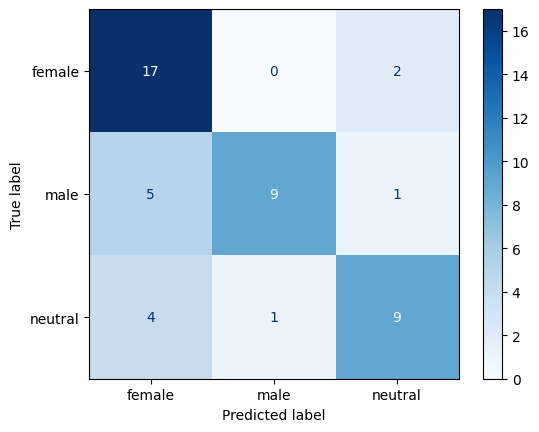

In [230]:
text_pipe.fit(X_train, y_train)

# Making predictions
y_pred_train = text_pipe.predict(X_train)
y_pred_test = text_pipe.predict(X_test)

# Accuracy scores
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))


cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["female","male","neutral"])
disp.plot(cmap='Blues');

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

In [231]:
param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)],  # Test unigrams and bigrams
    'tfidf__min_df': [0.01, 0.05],         # Test different min document frequencies
    'rf_clf__n_estimators': [50, 100],     # Number of trees in the forest
    'rf_clf__max_depth': [2, 10, None],    # Maximum depth of the tree
    'rf_clf__max_features': [100, 'sqrt'], # Number of features to consider
    'rf_clf__max_leaf_nodes': [8, None]    # Maximum number of leaf nodes
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=text_pipe,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

# Fit the grid search to your data
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters: {'rf_clf__max_depth': 2, 'rf_clf__max_features': 100, 'rf_clf__max_leaf_nodes': 8, 'rf_clf__n_estimators': 50, 'tfidf__min_df': 0.05, 'tfidf__ngram_range': (1, 1)}
Best cross-validation score: 0.8047619047619048


PRINTING CONFUSION MATRIX WITH BEST MODEL FROM GridSearch

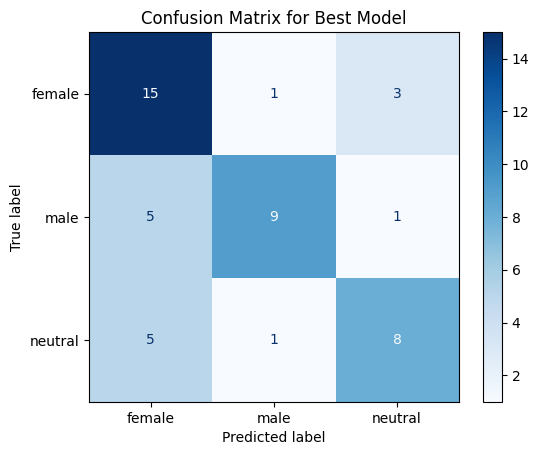


Classification Report:
              precision    recall  f1-score   support

      female       0.60      0.79      0.68        19
        male       0.82      0.60      0.69        15
     neutral       0.67      0.57      0.62        14

    accuracy                           0.67        48
   macro avg       0.69      0.65      0.66        48
weighted avg       0.69      0.67      0.67        48

Train Accuracy: 0.9166666666666666
Test Accuracy: 0.7291666666666666


In [232]:
best_model = grid_search.best_estimator_

# Make predictions on test set
y_pred = best_model.predict(X_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Best Model')
plt.show()

# Print classification report for more metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Accuracy scores
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

# LOGISTIC REGRESSION 

In [233]:
text_pipe_log = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,1), min_df=0.05, max_df=0.95, stop_words='english')),
    ('logreg', LogisticRegression(solver='lbfgs', random_state=0))
])

# Fitting the pipeline to our training data
text_pipe_log.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=0.05,
                                 stop_words='english')),
                ('logreg', LogisticRegression(random_state=0))])

In [234]:
# Define parameter grid for tuning
param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [0.01, 0.05],
    'tfidf__max_df': [0.9, 0.95],
    'logreg__solver': ['lbfgs', 'sag'],
    'logreg__C': [0.1, 1, 10],  # Inverse of regularization strength
    'logreg__penalty': ['l2', None],
    'logreg__max_iter': [100, 200]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=text_pipe_log,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

In [235]:
# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters: {'logreg__C': 1, 'logreg__max_iter': 100, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs', 'tfidf__max_df': 0.9, 'tfidf__min_df': 0.05, 'tfidf__ngram_range': (1, 1)}


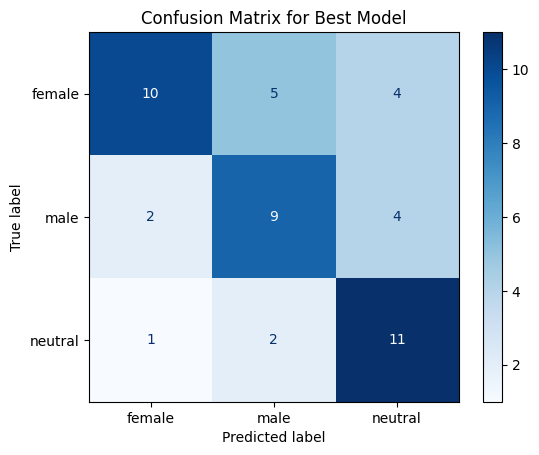


Classification Report:
              precision    recall  f1-score   support

      female       0.77      0.53      0.62        19
        male       0.56      0.60      0.58        15
     neutral       0.58      0.79      0.67        14

    accuracy                           0.62        48
   macro avg       0.64      0.64      0.62        48
weighted avg       0.65      0.62      0.62        48



In [236]:

# Get best model and predictions
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Best Model')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [237]:

# Accuracy scores
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

Train Accuracy: 0.9166666666666666
Test Accuracy: 0.7291666666666666


In [256]:
# Get the feature names (words) from the TfidfVectorizer
feature_names = text_pipe_log.named_steps['tfidf'].get_feature_names_out()

# Get the classifier coefficients
coefficients = text_pipe_log.named_steps['logreg'].coef_

# Get the class names
classes = text_pipe_log.named_steps['logreg'].classes_

# Extract top words for each class
top_words_dict = {}
top_n = 100  # number of top words to consider per class

for i, cls in enumerate(classes):
    coef = coefficients[i]
    sorted_indices = coef.argsort()[::-1]  # indices sorted descending by weight
    top_words = [feature_names[idx] for idx in sorted_indices]
    top_words_dict[cls] = top_words[:top_n]

# Ensure exclusivity (remove words that appear in multiple classes' top words)
exclusive_words = {}
for cls in top_words_dict:
    exclusive = []
    for word in top_words_dict[cls]:
        # Check if this word appears in any other class's top words
        appears_elsewhere = any(word in top_words_dict[other_cls] 
                               for other_cls in top_words_dict if other_cls != cls)
        if not appears_elsewhere:
            exclusive.append(word)
    exclusive_words[cls] = exclusive

# Display the resulting exclusive discriminating words per class
print("Discriminating words per class (exclusive):")
for cls, words in exclusive_words.items():
    print(f"{cls}: {words}")

Discriminating words per class (exclusive):
female: ['hair', 'woman', 'dye', 'shampoo', 'blade', 'conditioner', 'spray', 'perfume', 'oil', 'scent', 'soft', 'colour', 'sure', 'vanilla', 'refill', 'handle', 'shine', 'body', 'brush', 'blend', 'natural', 'permanent', 'flame', 'leaf', 'routine', 'month', 'sweat', 'eye', 'extra', 'underarm', 'ready', 'glass', 'hold', 'test', 'little', 'design', 'dry', 'close', 'new', 'start', 'light', 'evenly', 'brushing', 'care', 'root', 'shake', 'coverage', 'second', 'heat', 'hand', 'leave', 'gentle', 'short', 'gently', 'application', 'barrier', 'form', 'follow', 'external', 'touch', 'plant', 'bottle', 'bath', 'grip', 'safe', 'better', 'confidence', 'future', 'rash', 'week', 'use', 'nourishing', 'flammable', 'technology', 'styling', 'eu', 'rinse', 'create', 'infinitely', 'read', 'apply', 'come']
male: ['men', 'shaving', 'gel', 'shave', 'razor', 'foam', 'face', 'head', 'bergamot', 'comfortable', 'blue', 'roll', 'shower', 'power', 'fresh', 'electric', 'comfo

# DOODLES

In [ ]:

# Get best model and predictions
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [193]:
#### CREATE COUNT MODELS
vect = CountVectorizer(
                        ngram_range=(1, 1),
                        stop_words='english',
                        lowercase=True)
                        #max_df=0.99, 
                        #min_df=0.01)
                        
vect_norm = TfidfVectorizer(
                            ngram_range=(1, 1),
                            stop_words='english',
                            lowercase=True)
                            #max_df= 0.99, 
                            #min_df= 0.01)

In [ ]:
X_train_dfm = vect.fit_transform(X_train["processed"])
X_test_dfm = vect.transform(X_test["processed"])

In [213]:
X_train_df = pd.DataFrame(
    X_train_dfm.toarray(),
    columns=vect.get_feature_names_out()
)

X_test_df = pd.DataFrame(
    X_test_dfm.toarray(),
    columns=vect.get_feature_names_out()
)

In [214]:
X_train_df

,absorbable,absorbed,abuse,access,accessory,accordance,according,accurate,achieve,acid,...,wrist,write,year,yellow,yes,young,yummy,zest,zinc,zone
0,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,1,0,0,1,0,0,...,0,0,1,0,0,1,0,0,1,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [215]:
model = RandomForestClassifier(n_estimators=10**2, random_state=0)

In [216]:
model.fit(X_train_df, y_train["human_label"])

RandomForestClassifier(random_state=0)

In [217]:
X_train_dfm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6194 stored elements and shape (60, 1455)>

In [218]:
model.predict(X_test_dfm)

c:\Users\jarem\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array(['neutral', 'neutral', 'female', 'neutral', 'male', 'female',
       'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'female',
       'neutral', 'neutral', 'neutral', 'male', 'female', 'neutral',
       'male', 'neutral', 'male', 'neutral', 'female', 'male', 'neutral',
       'neutral', 'neutral', 'male', 'neutral', 'female', 'neutral',
       'male', 'neutral', 'male', 'neutral', 'neutral', 'female',
       'neutral', 'male', 'neutral', 'neutral', 'female', 'neutral',
       'male', 'neutral', 'neutral', 'neutral', 'male', 'neutral',
       'neutral', 'female', 'neutral', 'neutral', 'neutral', 'female',
       'neutral', 'male', 'male', 'neutral', 'female'], dtype=object)

In [219]:
# Creating a pipeline with our desired steps
#gender_classification_pipe = Pipeline(
#    [
#        ('tfidf', vect_norm),
#        ('rf_clf', RandomForestClassifier(n_estimators=10**2, random_state=0))
#     ]
#)

# Fitting the pipeline to our training data
#gender_classification_pipe.fit(X_train_dfm, y_train)

In [220]:
X_test_dfm = vect.transform(X_test["processed"])

In [221]:
#X_test_dfm = pd.DataFrame(
    #X_test_dfm .toarray(),
    #columns=vect.get_feature_names_out()
#)

In [222]:
y_train

,,human_label
product_id,store_id,
112371076,4,male
305038915,1,male
316558248,1,neutral
109747941,4,female
107576325,4,female
8007265,2,neutral
8194828,2,neutral
110620260,4,male
6916214,2,male


In [223]:
# Encode labels (convert to numerical values)
#le = LabelEncoder()
#y_train = le.fit_transform(y_train["human_label"])
#y_test = le.transform(y_test["human_label"])

# Create pipeline with feature hashing and multiclass logistic regression
#model = make_pipeline(
#    HashingVectorizer(n_features=1000, alternate_sign=False),
#    LogisticRegression(
#        multi_class='multinomial',  # Explicitly set for multiclass
#        solver='lbfgs',            # Good for multiclass problems
#        max_iter=1000,             # Ensure convergence
#        random_state=42
#    )
#)

In [224]:
# Train the model
#model.fit(X_train_dfm, y_train)

# Predict on test set
#y_pred = model.predict(X_test_dfm)

# Decode predictions back to original labels
#predicted_labels = le.inverse_transform(y_pred)

# Evaluate
#print("Classification Report:")
#print(classification_report(test_df['label'], predicted_labels))
#print("\nTest Set Predictions:")
#for text, pred in zip(test_df['text'], predicted_labels):
#    print(f"Text: {text:20} → Predicted: {pred}")

In [938]:
# Train the model
#model.fit(X_train_dfm['processed'], y_train)

# Predict on test set
#y_pred = model.predict(X_test_dfm['processed'])

# Decode predictions back to original labels
#predicted_labels = le.inverse_transform(y_pred)

In [225]:
clf = LogisticRegression(multi_class='ovr', max_iter=10000)
clf.fit(X_train_dfm, y_train)

c:\Users\jarem\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\jarem\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=10000, multi_class='ovr')

In [226]:

# 6. Extract the discriminating words based on the model’s coefficients.
#    For each class, we sort the coefficients (features) and select the top N words.
top_words_dict = {}
top_n = 100  # number of top words to consider per class

for i, cls in enumerate(clf.classes_):
    coef = clf.coef_[i]
    sorted_indices = coef.argsort()[::-1]  # indices sorted descending by weight
    # Filter out any words that appear in the regex keywords list
    top_words = [feature_names[idx] for idx in sorted_indices if feature_names[idx] not in regex_keywords]
    top_words_dict[cls] = top_words[:top_n]

# 7. Ensure exclusivity:
#    For each gender class, remove words that also appear among the top words of any other class.
exclusive_words = {}
for cls in top_words_dict:
    exclusive = []
    for word in top_words_dict[cls]:
        # Check if this word appears in any other class's top words
        appears_elsewhere = any(word in top_words_dict[other_cls] for other_cls in top_words_dict if other_cls != cls)
        if not appears_elsewhere:
            exclusive.append(word)
    exclusive_words[cls] = exclusive

# Display the resulting exclusive discriminating words per gender
print("Discriminating words per gender (exclusive):")
for gender, words in exclusive_words.items():
    print(f"{gender}: {words}")

NameError: name 'feature_names' is not defined

## Add explicit gendering

In [280]:
#conditions = [
    #(df['is_male'] == 1),
    #(df['is_female'] == 1),
    #(df['is_neutral'] == 1)
#]
#labels = ['male', 'female', 'neutral']
#df['keyword_gender'] = np.select(conditions, labels, default='unknown')

#df.drop(columns=["is_male","is_female","is_neutral"],inplace=True)

df.head(1)

,store_id,product_id,processed,category,human_label,keyword_gender
0,2,1111071,thick bleach lemon l thick bleach citrus thick bleach citrus deterrent thick bleach citrus kill bacteria salmonella e coli flu virus used neat kill tested surrogate following en leaf fresh perfume remove stain help prevent formation safe use septic tank grocery household household essential thick bleach lemon l,Cleaning Liquid,NaN,neutral


In [263]:
overlapping_rows = ((df[['is_male', 'is_female', 'is_neutral']].sum(axis=1)) > 1).sum()
summary_stats = df[['is_male', 'is_female', 'is_neutral']].sum().reset_index()
summary_stats.columns = ['gender', 'number of classifications']

display(summary_stats)

display(f"Number of rows with multiple binary columns set to 1: {overlapping_rows}")

,gender,number of classifications
0,is_male,998
1,is_female,676
2,is_neutral,4302


'Number of rows with multiple binary columns set to 1: 0'

## CountVecotrisation + logistic regression

In [ ]:

# 3. Vectorize the text data.
#    You might want to remove stopwords and work with lowercase tokens.
vectorizer = CountVectorizer(lowercase=True, stop_words='english', max_df=0.99, min_df=0.01)
X = vectorizer.fit_transform(texts)
feature_names = np.array(vectorizer.get_feature_names_out())

# 4. Prepare your target variable.
#    Here we assume that each row has only one gender set to 1.
#    We create a single label ('male', 'female', or 'neutral') for each row.
y = df[['is_male', 'is_female', 'is_neutral']].apply(
    lambda row: 'male' if row['is_male'] == 1 else ('female' if row['is_female'] == 1 else 'neutral'),
    axis=1
)

# 5. Train a classifier.
#    Using Logistic Regression in a one-vs-rest scheme.
clf = LogisticRegression(multi_class='ovr', max_iter=10000)
clf.fit(X, y)

# 6. Extract the discriminating words based on the model’s coefficients.
#    For each class, we sort the coefficients (features) and select the top N words.
top_words_dict = {}
top_n = 100  # number of top words to consider per class

for i, cls in enumerate(clf.classes_):
    coef = clf.coef_[i]
    sorted_indices = coef.argsort()[::-1]  # indices sorted descending by weight
    # Filter out any words that appear in the regex keywords list
    top_words = [feature_names[idx] for idx in sorted_indices if feature_names[idx] not in regex_keywords]
    top_words_dict[cls] = top_words[:top_n]

# 7. Ensure exclusivity:
#    For each gender class, remove words that also appear among the top words of any other class.
exclusive_words = {}
for cls in top_words_dict:
    exclusive = []
    for word in top_words_dict[cls]:
        # Check if this word appears in any other class's top words
        appears_elsewhere = any(word in top_words_dict[other_cls] for other_cls in top_words_dict if other_cls != cls)
        if not appears_elsewhere:
            exclusive.append(word)
    exclusive_words[cls] = exclusive

# Display the resulting exclusive discriminating words per gender
print("Discriminating words per gender (exclusive):")
for gender, words in exclusive_words.items():
    print(f"{gender}: {words}")


c:\Users\jarem\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Discriminating words per gender (exclusive):
female: ['removal', 'people', 'preservative', 'vegetarian', 'nutrient', 'mist', 'hormonal', 'pink', 'broken', 'quickly', 'contribute', 'gluten', 'dermatologist', 'selenium', 'sweat', 'dose', 'certified', 'riboflavin', 'seed', 'source', 'strengthen', 'diet', 'doe', 'excellent', 'intended', 'nutrition', 'salon', 'medicine', 'consumer', 'wet', 'lemon', 'winner', 'jar', 'liquid', 'brain', 'feature', 'design', 'wrinkle', 'perfect', 'firmer', 'possible', 'cotton', 'lightweight', 'cognitive', 'queen', 'mental', 'nongreasy', 'lasting', 'bar', 'coated', 'developer', 'taken', 'activity', 'shave', 'ammonia', 'neutral', 'increase', 'supplement', 'like', 'step', 'formulation', 'person', 'matter', 'advanced', 'loral', 'impurity', 'acid', 'yeast', 'battery', 'chewy', 'pore', 'almond', 'product', 'sweetener', 'time', 'mineral', 'secret', 'market', 'defined', 'herb', 'nervous', 'award', 'reduce', 'global', 'active', 'dark', 'aerosol', 'deliver', 'chew', 'sty

#

# TF-IDF Vectorization + Mutual Information

In [201]:
y = df[['is_male', 'is_female', 'is_neutral']].apply(
    lambda row: 'male' if row['is_male'] == 1 else ('female' if row['is_female'] == 1 else 'neutral'),
    axis=1
)

# Convert y to categorical (if needed)
y = pd.Categorical(y)

from sklearn.preprocessing import Binarizer

# Apply binarization to the TF-IDF matrix
binarizer = Binarizer()
X_binarized = binarizer.fit_transform(X_tfidf)

# 2. Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', max_features=5000)
X_tfidf = vectorizer.fit_transform(df['processed'].fillna(""))

# 3. Compute Mutual Information scores
mi_scores = mutual_info_classif(X_tfidf, y, discrete_features=False)

# 4. Extract the top words for each gender
feature_names = np.array(vectorizer.get_feature_names_out())

# Create a dictionary to store top words per gender
top_words_dict = {}
n_top_words = 20  # Number of top words to extract

# Compute MI scores separately for each class
for gender in ['male', 'female', 'neutral']:
    # Mask for current gender
    mask = (y == gender).values

    # MI scores specific to the current gender
    mi_scores_gender = mutual_info_classif(X_tfidf[mask], [gender] * sum(mask), discrete_features=False)
    
    # Sort and extract top N words
    top_indices = np.argsort(mi_scores_gender)[::-1][:n_top_words]
    top_words = feature_names[top_indices]
    
    # Store the result
    top_words_dict[gender] = top_words.tolist()

# Display the results
print("\n🔥 Top Discriminating Words by Gender (TF-IDF + Mutual Information):")
for gender, words in top_words_dict.items():
    print(f"{gender}: {words}")

ValueError: Sparse matrix `X` can't have continuous features.

## Naive Bayes + Log Probabilities

In [199]:
from sklearn.naive_bayes import MultinomialNB

# 1. Fit a Multinomial Naive Bayes model
mnb = MultinomialNB()
mnb.fit(X_tfidf, y)

# 2. Extract log probabilities
#    Each row corresponds to a class (male, female, neutral)
log_probs = mnb.feature_log_prob_

# 3. Map log probabilities to gender labels
top_words_dict_nb = {}
n_top_words = 20  # Number of top words

# Extracting top discriminating words for each gender
for idx, gender in enumerate(mnb.classes_):
    # Sort features by log probability
    top_indices = np.argsort(log_probs[idx])[::-1][:n_top_words]
    top_words = feature_names[top_indices]
    
    # Store the result
    top_words_dict_nb[gender] = top_words.tolist()

# Display the results
print("\n🔥 Top Discriminating Words by Gender (Naive Bayes Log Probabilities):")
for gender, words in top_words_dict_nb.items():
    print(f"{gender}: {words}")


IndexError: index 4927 is out of bounds for axis 0 with size 1031

In [186]:
female_ratio = sum(gender == "female") / len(gender)
male_ratio = sum(gender == "male") / len(gender)
neutral_ratio = sum(gender == "neutral") / len(gender)

print(f"Classified as female: {female_ratio:.2%}")
print(f"Classified as male: {male_ratio:.2%}")
print(f"Classified as neutral: {neutral_ratio:.2%}")

TypeError: 'bool' object is not iterable

In [104]:
neutrals = df[(gender == "neutral") & (df["processed"] != "nan")]["processed"]
# neutrals = neutrals.drop(["product_id", "store_id", "gender_breadcrumb"], axis=1)
neutrals.info()

<class 'pandas.core.series.Series'>
Index: 3539 entries, 0 to 5964
Series name: processed
Non-Null Count  Dtype 
--------------  ----- 
3539 non-null   object
dtypes: object(1)
memory usage: 55.3+ KB


In [30]:
females = df[(gender == "female") & (df["processed"] != "nan")]["processed"]
# neutrals = neutrals.drop(["product_id", "store_id", "gender_breadcrumb"], axis=1)
females.info()

<class 'pandas.core.series.Series'>
Index: 431 entries, 17 to 5888
Series name: processed
Non-Null Count  Dtype 
--------------  ----- 
431 non-null    object
dtypes: object(1)
memory usage: 6.7+ KB


In [31]:
males = df[(gender == "male") & (df["processed"] != "nan")]["processed"]
# neutrals = neutrals.drop(["product_id", "store_id", "gender_breadcrumb"], axis=1)
males.info()

<class 'pandas.core.series.Series'>
Index: 695 entries, 48 to 5954
Series name: processed
Non-Null Count  Dtype 
--------------  ----- 
695 non-null    object
dtypes: object(1)
memory usage: 10.9+ KB


## Males

In [ ]:
males_vect = vect_norm.fit_transform(males)

# create DFM
males_dfm = pd.DataFrame(
    males_vect.toarray(),
    columns=vect_norm.get_feature_names_out()
)

In [88]:
males_dfm

,accessory,accurate,additional,adult,advice,aerosol,aim,alcohol,allergen,allergy,...,wash,water,way,welcome,whats,whatsoever,woman,work,world,zinc
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.086215,0.086215
1,0.0,0.0,0.0,0.063945,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.092668,0.0,0.106128,0.000000
2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.122608,0.150269,0.0,0.0,0.054843,0.0,0.044670,0.0,0.000000,0.000000
3,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.122541,0.150187,0.0,0.0,0.054812,0.0,0.044646,0.0,0.000000,0.000000
4,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.179391,0.131917,0.0,0.0,0.048145,0.0,0.039215,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
691,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.105640
692,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
693,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000


In [ ]:
male_common_words = ((males_dfm > 0).sum() / len(males_dfm))
male_common_words = pd.DataFrame(male_common_words, columns=["frequencies"])
male_common_words.index.name = 'words'
display(male_common_words.sort_values(by="frequencies", ascending=False).head(30))

,frequencies
words,
use,0.631655
skin,0.621583
day,0.618705
ha,0.592806
need,0.576978
designed,0.574101
feature,0.569784
product,0.526619
experience,0.520863


## Females

In [93]:
females_vect = vect_norm.fit_transform(females)

# create DFM
females_dfm = pd.DataFrame(
    females_vect.toarray(),
    columns=vect_norm.get_feature_names_out()
)

In [94]:
females_dfm

,accessory,accurate,acid,additional,adult,advanced,advice,aerosol,alcohol,allergen,...,water,way,week,whatsoever,white,wont,work,world,year,zinc
0,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.00000,0.0,0.0,0.0,0.067438,0.083214,0.149851,0.000000
1,0.0,0.0,0.323881,0.092613,0.0,0.00000,0.047614,0.0,0.0,0.0,...,0.0,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.141297
2,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.05469,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.04967,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
427,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.200487,0.000000
428,0.0,0.0,0.204596,0.000000,0.0,0.07357,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.148762
429,0.0,0.0,0.387691,0.055430,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.169135


In [95]:
female_common_words = ((females_dfm > 0).sum() / len(females_dfm))
female_common_words = pd.DataFrame(female_common_words, columns=["frequencies"])
female_common_words.index.name = 'words'
display(female_common_words.sort_values(by="frequencies", ascending=False).head(30))

,frequencies
words,
day,0.647332
skin,0.624130
designed,0.582367
use,0.575406
ha,0.556845
help,0.529002
need,0.529002
brand,0.505800
product,0.496520


## Neutrals

In [97]:
neutrals_vect = vect_norm.fit_transform(neutrals)

# create DFM
neutrals_dfm = pd.DataFrame(
    neutrals_vect.toarray(),
    columns=vect_norm.get_feature_names_out()
)

In [99]:
neutral_common_words = ((neutrals_dfm > 0).sum() / len(neutrals_dfm))
neutral_common_words = pd.DataFrame(neutral_common_words, columns=["frequencies"])
neutral_common_words.index.name = 'words'
display(neutral_common_words.sort_values(by="frequencies", ascending=False).head(30))

,frequencies
words,
use,0.537440
product,0.479797
ha,0.470189
care,0.467646
ingredient,0.467364
day,0.457474
help,0.433738
food,0.428370
designed,0.413959


## Use LLM to create a dictionary for ADM

In [ ]:
# Gendered words dictionary for product packaging
gendered_words = {
    "feminine": [
        "gentle", "soft", "delicate", "radiant", "luminous", "soothing", "dewy",
        "floral", "elegance", "grace", "charm", "blossom", "rose", "pearl", "flower" , "nurturing", "nutritious"
        "for her", "designed for women", "feminine touch" , "volume" , "voluminous", "young" 
    ],
    "masculine": [
        "strong", "rugged", "bold", "powerful", "athletic", "robust", "tough",
        "strength", "force", "cedarwood", "musk", "steel", "for him",
        "engineered for men", "masculine scent", "beast", 
    ],
    "neutral": [
        "fresh", "clean", "natural", "eco-friendly", "sustainable", "modern",
        "quality", "care", "innovation", "balance", "nature"
    ]
}


In [ ]:
female_keywords = {
    "female": {
        "food_beverages": [
            "guilt-free", "nourishing", "wholesome", "superfood", "antioxidant-rich",
            "low-calorie", "dairy-free", "revitalizing", "revitilize", "revitilise","revitilising", "skin-boosting", "detoxifying",
            "pure", "farm-to-table", "probiotic", "vitamin-packed", "heart-healthy",
            "indulgent", "crave-worthy", "mood-enhancing", "meal-prep-friendly"
        ],
        "clothing_apparel": [
            "flattering", "figure", "hugging", "chic", "feminine", "tailored",
            "confidence-boosting", "soft-to-the-touch", "curve-loving", "luxe",
            "couture-inspired", "occasion-ready", "wrinkle-resistant", "seasonless",
            "trend-forward", "size-inclusive"
        ],
        "beauty_skincare": [
            "hydrating", 
            "radiant", 
            "rejuvenating", 
            "age-defying", 
            "anti-aging",
            "glow-boosting", 
            "non-comedogenic", 
            "beauty", 
            "paraben-free",
            "sulfate-free", 
            "luminous", 
            "plumping", 
            "firming", 
            "brightening", 
            "plumed", 
            "hug", 
            "moisturizing", 
            "moisture", 
            "glitter", 
            "sensitive", 
            "pore-minimizing", 
            "pore-minimising",
            "spa-like", 
            "silky", 
            "velvety", 
            "velvet",
            "smudge-proof", 
            "pamper", 
            "young", 
            "elegant", 
            "elegance", 
            "pampering", 
            "clinically proven", 
            "sensitive-skin-friendly", 
            "revitalizing", 
            "revitilize", 
            "revitilise",
            "revitilising", 
            "miracle",
            "miracolous", 
            "frizzy",
            "luxuriously",
            "luxurious",
            "luxury",
            "sleek",
            "smoothness",
            "gently",
            "restore",
            "restoring",
            "macadamia",
            "moist",
            "moisturizes",
            "moisturises",
            "gentle", 
            "soft", 
            "delicate", 
            "radiant", 
            "luminous", 
            "soothing", 
            "dewy", 
            "floral", 
            "elegance", 
            "grace", 
            "charm", 
            "blossom", 
            "rose", 
            "pearl", 
            "flower", 
            "sensational",
            "sensual",
            "nurturing", 
            "nutritious",
            "her",
            "hers", 
            "designed for women", 
            "feminine touch" , 
            "volume" , 
            "voluminous", 
            "spoil", 
            "nourishing", 
            "avocado oil", 
            "radiating", 
            "smooth", 
            "coloured", 
            "colour", 
            "coloured-hair", 
            "shine",             
            "vibrancy", 
            "restore", 
            "restoring", 
            "regenerate", 
            "haircare", 
            "care", 
            "skincare", 
            "harmony", 
            "feel", 
            "healthy", 
            "vibrant", 
            "feminine",
            "women",
            "woman",
            "woman's",
            "women's"
        ],
        "cross_category": [
            "empowering", "curated", "personalized", "transformative", "mindful",
            "bespoke", "award-winning", "iconic", "must-have", "essentials",
            "perfect for you", "perfect for everyday"
        ]
    }
}

male_keywords = {
    "male": {
        "food_beverages": [
            "muscle-fuel", "keto-friendly", "low-carb", "energy-packed", "grass-fed",
            "no-added-sugar", "hearty", "bold flavors", "crafted", "smoked",
            "slow-cooked", "testosterone-supporting", "crunchy", "grillable",
            "fuel-for-the-day"
        ],
        "clothing_apparel": [
            "rugged", "moisture-wicking", "quick-dry", "athletic-fit", "slim-fit",
            "classic-cut", "performance-ready", "stretch-flex", "reinforced",
            "heavy-duty", "weather-resistant", "odour-resistant", "anti-microbial",
            "workwear-inspired", "built-to-last", "multi-pocket", "tech-friendly"
        ],
        "beauty_grooming": [
            "barber-approved", 
            "beard-friendly", 
            "anti-itch", 
            "long-lasting hold",
            "oil-free", 
            "matte finish", 
            "exfoliating", 
            "charcoal-infused",
            "post-shave", 
            "fade-resistant", "strengthening", 
            "travel-sized",
            "tattoo-safe", 
            "sweat-proof", 
            "protect",
            "ice",
            "iced",
            "zesty",
            "citrus",
            "chest",
            "irresistible",
            "sweat",
            "fight",
            "kill",
            "men's",
            "man's",
            "bold", 
            "no-nonsense", 
            "masculine", 
            "streamlined", 
            "modern",
            "go-anywhere", 
            "built-tough", 
            "precision-engineered",
            "mission-critical", 
            "uncompromising", 
            "lean",
            "attack",
            "strengthen",
            "stronger",
            "strongest",
            "bulldog",
            "technology",
            "odour-control",
            "odor-control",
            "masculine",
            "balanced",
            "engineered",
            "engineering",
            "confidence",
            "odor",
            "odour",
            "his",
            "him",
            "he",
            "men",
            "male",
            "man",
            "father",
            "son",
            "yourself",
            "be yourself",
            
            
            
        ]
    }
}

neutral_keywords = {
    "neutral": {
        "food_beverages": [
            "sustainably sourced", "organic", "plant-based", "non-GMO", "low-waste",
            "nutrient-dense", "ethically produced", "allergy-friendly", "gluten-free",
            "vegan", "fair-trade", "minimally processed", "whole-food", "balanced",
            "energy-boosting", "immune-supporting", "hydrating", "seasonal",
            "locally grown", "recyclable packaging", "zero-added-sugar", "flexitarian",
            "climate-friendly", "compostable", "mindfully crafted"
        ],
        "clothing_apparel": [
            "unisex", "size-inclusive", "eco-friendly", "versatile", "durable",
            "breathable", "easy-care", "timeless", "minimalist", "adjustable",
            "lightweight", "recycled materials", "modular", "gender-neutral fit",
            "functional", "adaptive", "travel-ready", "certified sustainable",
            "biodegradable", "packable", "long-lasting"
        ],
        "beauty_personal_care": [
            "gentle", 
            "hypoallergenic", 
            "fragrance-free", 
            "cruelty-free", 
            "reef-safe",
            "non-toxic", 
            "pH-balanced", 
            "zero-waste", 
            "dermatologist-tested",
            "sensitive-skin safe", 
            "refillable", 
            "waterless", 
            "carbon-neutral",
            "all-in-one", 
            "travel-friendly", 
            "plastic-free", 
            "universal",
            "transparent ingredients", 
            "ethically sourced", 
            "compostable packaging", 
            "clean",

            
            
        ],
        "cross_category": [
            "inclusive", "sustainable", "ethical", "innovative", "accessible",
            "adaptable", "transparent", "holistic", "universal", "eco-conscious",
            "future-proof", "community-driven", "thoughtfully designed",
            "quality-crafted", "multi-functional", "user-friendly", "planet-positive",
            "socially responsible"
        ]
    }
}

__Potential challenges__

1. How do we standardize prices to put it on the same scale?

    * option 1: create a categorical variable capturing the type of pricing -- but then how do you convert it into standardized df?

    * option 2 :bring to common denominator as much as possible


2. How do we study the gender price gap?

    * we need to find a way to assign the products into a category (female/male/neither)

3. What method do we study this with?

    * Moshary et al. 2023 use regression


__Pre-processing. Things to do__

- transform data to datetime object


Use one store info to categorize into female/male (Cyril's idea)